In [ ]:
# Network Anomaly Detection and Attack Classification using UNSW-NB15

In [ ]:
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'UNSW_NB15_training-set.csv', 'UNSW_NB15_testing-set.csv', 'sample_data']


In [ ]:
import pandas as pd

train = pd.read_csv("UNSW_NB15_training-set.csv")
test = pd.read_csv("UNSW_NB15_testing-set.csv")

print(train.shape)
print(test.shape)

train.head()


(82332, 45)
(175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
# Drop ID column if it exists
if "id" in train.columns:
    train = train.drop(columns=["id"])
if "id" in test.columns:
    test = test.drop(columns=["id"])

# Targets
y_train = train["label"]
y_test = test["label"]

# Features
X_train = train.drop(columns=["label", "attack_cat"])
X_test = test.drop(columns=["label", "attack_cat"])

# One-hot encoding
X_train = pd.get_dummies(X_train, columns=["proto", "service", "state"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["proto", "service", "state"], drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join="outer", axis=1, fill_value=0)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy: 0.9041981054060374

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     56000
           1       0.99      0.87      0.93    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.90    175341
weighted avg       0.92      0.90      0.91    175341



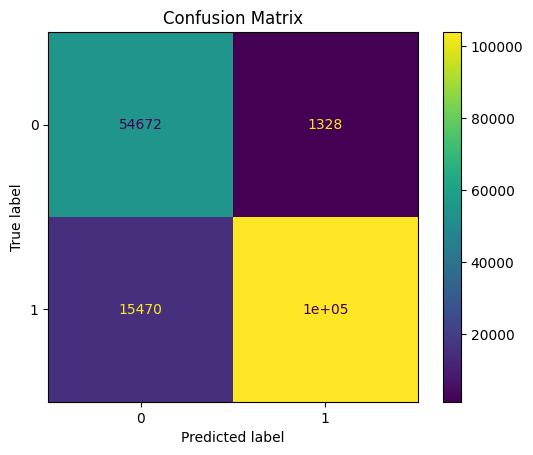

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

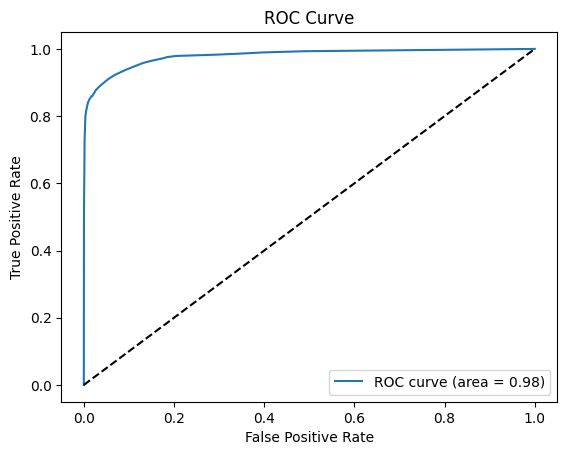

In [ ]:
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Attack Classification: classify malicious traffic by attack category

train_attack = train[train["label"] == 1].copy()
test_attack = test[test["label"] == 1].copy()

y_train_attack = train_attack["attack_cat"]
y_test_attack = test_attack["attack_cat"]

X_train_attack = train_attack.drop(columns=["label", "attack_cat"])
X_test_attack = test_attack.drop(columns=["label", "attack_cat"])

X_train_attack = pd.get_dummies(X_train_attack, columns=["proto", "service", "state"], drop_first=True)
X_test_attack = pd.get_dummies(X_test_attack, columns=["proto", "service", "state"], drop_first=True)

X_train_attack, X_test_attack = X_train_attack.align(
    X_test_attack, join="outer", axis=1, fill_value=0
)

from sklearn.ensemble import RandomForestClassifier

attack_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

attack_model.fit(X_train_attack, y_train_attack)

y_pred_attack = attack_model.predict(X_test_attack)

Attack Classification Report:
                precision    recall  f1-score   support

      Analysis       0.05      0.02      0.03      2000
      Backdoor       0.07      0.13      0.09      1746
           DoS       0.34      0.64      0.44     12264
      Exploits       0.80      0.57      0.67     33393
       Fuzzers       0.93      0.86      0.89     18184
       Generic       0.94      0.98      0.96     40000
Reconnaissance       0.92      0.73      0.81     10491
     Shellcode       0.60      0.55      0.58      1133
         Worms       0.73      0.12      0.21       130

      accuracy                           0.76    119341
     macro avg       0.60      0.51      0.52    119341
  weighted avg       0.80      0.76      0.77    119341



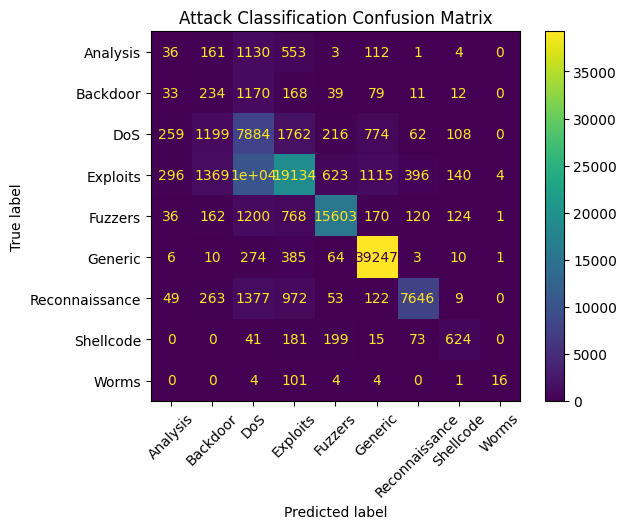

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Attack Classification Report:")
print(classification_report(y_test_attack, y_pred_attack))

cm_attack = confusion_matrix(y_test_attack, y_pred_attack, labels=attack_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_attack,
    display_labels=attack_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Attack Classification Confusion Matrix")
plt.show()

## Attack Classification Analysis

The multiclass attack classification model shows varying performance across different attack categories. High performance is observed for frequent attack types such as Generic and Reconnaissance, with F1-scores of 0.89 and 0.96 respectively.

However, the model performs poorly on less frequent classes such as Analysis, Backdoor, and Worms. This is primarily due to class imbalance in the dataset, where these attack types have significantly fewer samples, making them harder for the model to learn.

Overall, the model demonstrates strong performance on major attack categories but highlights the challenge of detecting rare network attacks, which is a common issue in cybersecurity datasets.

## Final Conclusion

This project successfully developed a network anomaly detection and attack classification system using the UNSW-NB15 dataset.

The binary classification model achieved approximately 90% accuracy in distinguishing between normal and malicious traffic, demonstrating strong performance in detecting network anomalies.

The multiclass classification model further categorized malicious traffic into specific attack types. While performance was strong for common attack categories, lower performance on rare classes highlights the impact of class imbalance.

Overall, the system demonstrates the effectiveness of machine learning techniques for intrusion detection and provides a solid foundation for improving cybersecurity systems.